In [86]:
from regime_ml.data.common.loaders import load_dataframe
from regime_ml.utils.config import load_configs

cfg = load_configs()
regime_cfg = cfg["macro_data"]["regime_universe"]
processed_path = cfg["macro_data"]["regime_universe"]["processed_path"]
raw_features_path = cfg["macro_data"]["regime_universe"]["raw_features_path"]
ready_features_path = cfg["macro_data"]["regime_universe"]["ready_features_path"]
series_config = cfg["macro_data"]["regime_universe"]["series"]

In [89]:
df_raw = load_dataframe(raw_features_path)
df_ready = load_dataframe(ready_features_path)

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

df_na_raw = pd.DataFrame(data=df_raw.isna().sum(axis=1), columns=["na_count_raw"])  # type: ignore
df_na_ready = pd.DataFrame(data=df_ready.isna().sum(axis=1), columns=["na_count_ready"])  # type: ignore

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_na_raw.index, y=df_na_raw["na_count_raw"], mode="lines"))
fig.add_trace(
    go.Scatter(x=df_na_ready.index, y=df_na_ready["na_count_ready"], mode="lines")
)
fig.update_layout(
    title="Number of NA values per day",
    xaxis_title="Date",
    yaxis_title="Number of NA values",
)
fig.show()

In [91]:
px.line(df_ready)

In [57]:
df_processed = load_dataframe(processed_path)
df_processed[(df_processed.series_code == "CFNAI")]

,date,series_code,value,series_name,category,is_new_data,native_freq,obs_number,days_since_update
0,2000-01-07,CFNAI,0.15,chicago_fed_national_activity_index,growth,None,monthly,1.0,4.0
1,2000-01-10,CFNAI,0.15,chicago_fed_national_activity_index,growth,None,monthly,1.0,7.0
2,2000-01-11,CFNAI,0.15,chicago_fed_national_activity_index,growth,None,monthly,1.0,8.0
3,2000-01-12,CFNAI,0.15,chicago_fed_national_activity_index,growth,None,monthly,1.0,9.0
4,2000-01-13,CFNAI,0.15,chicago_fed_national_activity_index,growth,None,monthly,1.0,10.0
...,...,...,...,...,...,...,...,...,...
6520,2026-01-09,CFNAI,-0.31,chicago_fed_national_activity_index,growth,None,monthly,308.0,161.0
6521,2026-01-12,CFNAI,-0.31,chicago_fed_national_activity_index,growth,None,monthly,308.0,164.0
6522,2026-01-13,CFNAI,-0.31,chicago_fed_national_activity_index,growth,None,monthly,308.0,165.0
6523,2026-01-14,CFNAI,-0.31,chicago_fed_national_activity_index,growth,None,monthly,308.0,166.0


<Axes: >

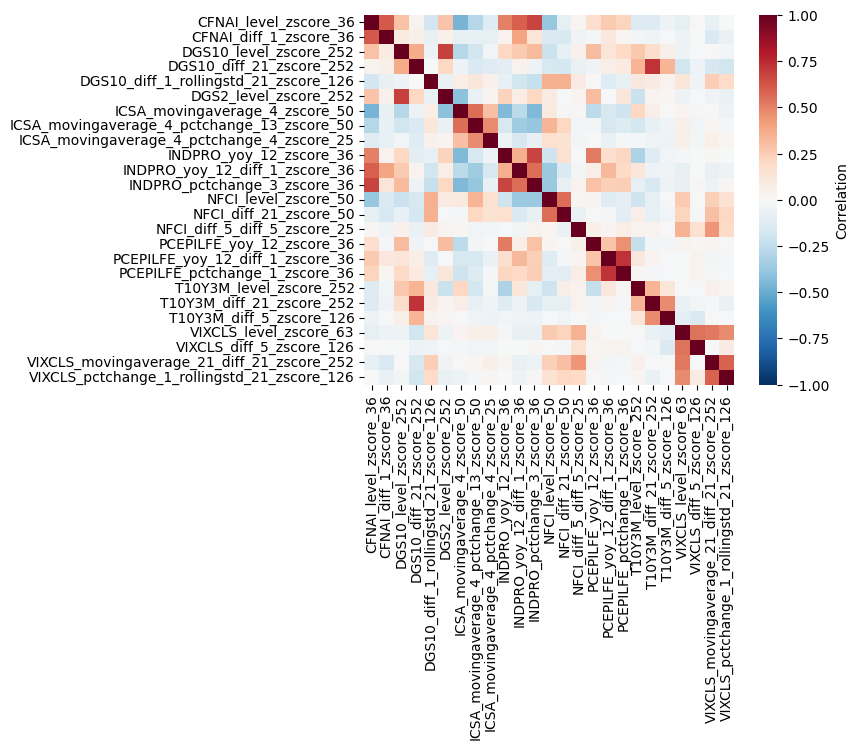

In [76]:
import seaborn as sns

df_feat = load_dataframe(features_path)
corr_matrix = df_feat.corr()
sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Correlation"},
)

In [79]:
threshold = 0.70

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append(
                {
                    "feature_1": corr_matrix.columns[i],
                    "feature_2": corr_matrix.columns[j],
                    "correlation": corr_matrix.iloc[i, j],
                }
            )

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "correlation", key=abs, ascending=False
)
high_corr_df

,feature_1,feature_2,correlation
0,DGS10_diff_21_zscore_252,T10Y3M_diff_21_zscore_252,0.726510
1,PCEPILFE_yoy_12_diff_1_zscore_36,PCEPILFE_pctchange_1_zscore_36,0.726292


In [78]:
df_feat.columns

Index(['CFNAI_level_zscore_36', 'CFNAI_diff_1_zscore_36',
       'DGS10_level_zscore_252', 'DGS10_diff_21_zscore_252',
       'DGS10_diff_1_rollingstd_21_zscore_126', 'DGS2_level_zscore_252',
       'ICSA_movingaverage_4_zscore_50',
       'ICSA_movingaverage_4_pctchange_13_zscore_50',
       'ICSA_movingaverage_4_pctchange_4_zscore_25', 'INDPRO_yoy_12_zscore_36',
       'INDPRO_yoy_12_diff_1_zscore_36', 'INDPRO_pctchange_3_zscore_36',
       'NFCI_level_zscore_50', 'NFCI_diff_21_zscore_50',
       'NFCI_diff_5_diff_5_zscore_25', 'PCEPILFE_yoy_12_zscore_36',
       'PCEPILFE_yoy_12_diff_1_zscore_36', 'PCEPILFE_pctchange_1_zscore_36',
       'T10Y3M_level_zscore_252', 'T10Y3M_diff_21_zscore_252',
       'T10Y3M_diff_5_zscore_126', 'VIXCLS_level_zscore_63',
       'VIXCLS_diff_5_zscore_126',
       'VIXCLS_movingaverage_21_diff_21_zscore_252',
       'VIXCLS_pctchange_1_rollingstd_21_zscore_126'],
      dtype='object')

In [80]:

features = load_dataframe(features_path)

In [83]:
features.dropna(inplace=True)
features

,CFNAI_level_zscore_36,CFNAI_diff_1_zscore_36,DGS10_level_zscore_252,DGS10_diff_21_zscore_252,DGS10_diff_1_rollingstd_21_zscore_126,DGS2_level_zscore_252,ICSA_movingaverage_4_zscore_50,ICSA_movingaverage_4_pctchange_13_zscore_50,ICSA_movingaverage_4_pctchange_4_zscore_25,INDPRO_yoy_12_zscore_36,...,PCEPILFE_yoy_12_zscore_36,PCEPILFE_yoy_12_diff_1_zscore_36,PCEPILFE_pctchange_1_zscore_36,T10Y3M_level_zscore_252,T10Y3M_diff_21_zscore_252,T10Y3M_diff_5_zscore_126,VIXCLS_level_zscore_63,VIXCLS_diff_5_zscore_126,VIXCLS_movingaverage_21_diff_21_zscore_252,VIXCLS_pctchange_1_rollingstd_21_zscore_126
date,,,,,,,,,,,,,,,,,,,,,
2004-09-01,0.670846,-0.353879,-0.783545,-1.522767,-1.178577,0.931447,-0.983241,1.754872,-0.322150,0.974285,...,0.887659,-0.554018,0.261887,-2.782093,-1.726660,-1.232830,-0.740279,-0.046479,1.043025,-0.676241
2004-09-02,0.670846,-0.353879,-0.505218,-1.016797,-1.094348,1.047965,-0.983241,1.754872,-0.322150,0.974285,...,0.887659,-0.554018,0.261887,-2.545516,-1.285370,-0.714941,-1.203928,-0.347798,0.970299,-0.643403
2004-09-03,0.670846,-0.353879,-0.108906,-0.654019,-0.390812,1.410699,-0.983241,1.754872,-0.322150,0.974285,...,0.887659,-0.554018,0.261887,-2.320569,-0.926159,0.015103,-1.444441,-0.436076,0.717767,-1.717939
2004-09-07,0.670846,-0.353879,-0.267180,-0.680249,-0.354045,1.325242,-0.983241,1.754872,-0.322150,0.974285,...,0.887659,-0.554018,0.261887,-2.466847,-1.039716,0.302675,-1.285177,-0.731750,0.412872,-1.988451
2004-09-08,0.670846,-0.353879,-0.581311,-0.860984,-0.099148,1.116748,-0.983241,1.754872,-0.322150,0.974285,...,0.887659,-0.554018,0.261887,-2.677593,-1.219277,0.086048,-1.267462,-0.644802,0.125762,-1.999884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-09,-0.659302,-0.521301,-0.651820,0.066605,-1.852276,-1.140217,-1.711126,-1.758988,-0.194653,2.723030,...,-0.920180,0.143440,-0.452106,2.616150,0.284109,-0.073909,-1.041595,0.017945,-0.981357,-0.939414
2026-01-12,-0.659302,-0.521301,-0.591691,0.409308,-2.147786,-1.140217,-2.305041,-1.693705,-0.864337,2.723030,...,-0.920180,0.143440,-0.452106,2.354055,0.040720,-0.433714,-0.818132,0.104185,-0.945262,-0.978579
2026-01-13,-0.659302,-0.521301,-0.642354,0.292310,-2.083307,-1.165987,-2.305041,-1.693705,-0.864337,2.723030,...,-0.920180,0.143440,-0.452106,2.264736,0.043305,-0.785699,-0.524435,0.476515,-0.895536,-0.982784


In [84]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

features_clean = features["2004-09-01":].dropna()

# Test each feature for stationarity
stationarity_results = []
for col in features_clean.columns:
    adf_result = adfuller(features_clean[col], autolag="AIC")
    stationarity_results.append(
        {
            "feature": col,
            "adf_statistic": adf_result[0],
            "p_value": adf_result[1],
            "stationary": adf_result[1] < 0.05,  # p < 0.05 = stationary
        }
    )

stationarity_df = pd.DataFrame(stationarity_results)
print(
    f"Stationary features: {stationarity_df['stationary'].sum()} / {len(stationarity_df)}"
)
print("\nNon-stationary features:")
print(stationarity_df[~stationarity_df["stationary"]])

Stationary features: 24 / 25

Non-stationary features:
                   feature  adf_statistic   p_value  stationary
9  INDPRO_yoy_12_zscore_36       -2.51091  0.112842       False


In [92]:
for col in features_clean.columns:
    print(col)

CFNAI_level_zscore_36
CFNAI_diff_1_zscore_36
DGS10_level_zscore_252
DGS10_diff_21_zscore_252
DGS10_diff_1_rollingstd_21_zscore_126
DGS2_level_zscore_252
ICSA_movingaverage_4_zscore_50
ICSA_movingaverage_4_pctchange_13_zscore_50
ICSA_movingaverage_4_pctchange_4_zscore_25
INDPRO_yoy_12_zscore_36
INDPRO_yoy_12_diff_1_zscore_36
INDPRO_pctchange_3_zscore_36
NFCI_level_zscore_50
NFCI_diff_21_zscore_50
NFCI_diff_5_diff_5_zscore_25
PCEPILFE_yoy_12_zscore_36
PCEPILFE_yoy_12_diff_1_zscore_36
PCEPILFE_pctchange_1_zscore_36
T10Y3M_level_zscore_252
T10Y3M_diff_21_zscore_252
T10Y3M_diff_5_zscore_126
VIXCLS_level_zscore_63
VIXCLS_diff_5_zscore_126
VIXCLS_movingaverage_21_diff_21_zscore_252
VIXCLS_pctchange_1_rollingstd_21_zscore_126
